# Stage 1: Random Forest Classification

The first machine learning model for Stage 1 is a Random Forest classifier.

It distinguishes earthquake waveform windows from background noise. Each input sample contains three-component seismic data, and each sample is assigned a binary label:

- `1`: earthquake
- `0`: noise

The Random Forest operates on numerical features extracted from the seismic waveforms. The feature set includes amplitude and frequency characteristics designed to represent properties of the recorded seismic signal.

The libraries below provide functionality for loading the prepared dataset, extracting numerical features, training the Random Forest classifier, and evaluating its predictions.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Loading feature extraction utilities

Feature extraction functions are imported from the project source code so that the same implementation is used across Random Forest experiments.

In [4]:
import sys
from pathlib import Path

# Add the project root directory to Python's import path
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.features import extract_features, build_feature_matrix

## Loading the Stage 1 development dataset

The detrended and bandpass-filtered Stage 1 development dataset is loaded for Random Forest feature extraction.

The same train, validation, and test splits created during dataset preparation are retained for all Random Forest experiments.

In [5]:
from pathlib import Path

processed_dir = Path("../data/processed")

data = np.load(
    processed_dir / "stage1_development_rf.npz"
)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (692, 3, 2000)
X_val:   (151, 3, 2000)
X_test:  (157, 3, 2000)
y_train: (692,)
y_val:   (151,)
y_test:  (157,)


## Creating the feature matrices

The feature extraction function is applied to every waveform in the training, validation, and test sets.

In [6]:
X_train_features = build_feature_matrix(X_train)
X_val_features = build_feature_matrix(X_val)
X_test_features = build_feature_matrix(X_test)

print("Training feature matrix:", X_train_features.shape)
print("Validation feature matrix:", X_val_features.shape)
print("Test feature matrix:", X_test_features.shape)

Training feature matrix: (692, 15)
Validation feature matrix: (151, 15)
Test feature matrix: (157, 15)


## Inspecting the extracted features

The extracted feature matrices are inspected before model training to identify unusual values, missing values, or features with unexpected ranges.

In [7]:
# Check feature names and missing values

print("Feature names:")
print(X_train_features.columns.tolist())

print("\nMissing values in training data:")
print(X_train_features.isna().sum())

print("\nFeature summary:")
display(X_train_features.describe().T)

Feature names:
['E_rms', 'E_peak', 'E_energy', 'E_dominant_frequency', 'E_spectral_centroid', 'N_rms', 'N_peak', 'N_energy', 'N_dominant_frequency', 'N_spectral_centroid', 'Z_rms', 'Z_peak', 'Z_energy', 'Z_dominant_frequency', 'Z_spectral_centroid']

Missing values in training data:
E_rms                   0
E_peak                  0
E_energy                0
E_dominant_frequency    0
E_spectral_centroid     0
N_rms                   0
N_peak                  0
N_energy                0
N_dominant_frequency    0
N_spectral_centroid     0
Z_rms                   0
Z_peak                  0
Z_energy                0
Z_dominant_frequency    0
Z_spectral_centroid     0
dtype: int64

Feature summary:


,count,mean,std,min,25%,50%,75%,max
E_rms,692.0,1.886815e+03,1.884287e+04,0.205803,6.695761,3.187990e+01,2.095043e+02,4.377589e+05
E_peak,692.0,1.676261e+04,1.855011e+05,0.934101,30.976325,1.669379e+02,1.299804e+03,3.444627e+06
E_energy,692.0,7.162016e+11,1.494168e+13,84.709685,89666.445757,2.032796e+06,8.780549e+07,3.832656e+14
E_dominant_frequency,692.0,8.146676e+00,4.558280e+00,2.650000,4.250000,6.600000e+00,1.125000e+01,2.385000e+01
E_spectral_centroid,692.0,1.056398e+01,2.121601e+00,4.870458,9.020585,1.068202e+01,1.195495e+01,1.672707e+01
N_rms,692.0,2.187643e+03,2.080764e+04,0.212502,6.310190,3.396871e+01,2.190901e+02,3.733780e+05
N_peak,692.0,2.677976e+04,3.145044e+05,0.837901,31.264516,1.856984e+02,1.198707e+03,6.126092e+06
N_energy,692.0,8.742359e+11,1.476870e+13,90.313914,79638.277402,2.307887e+06,9.600176e+07,2.788223e+14
N_dominant_frequency,692.0,8.238367e+00,4.522966e+00,2.600000,4.350000,6.675000e+00,1.125000e+01,2.165000e+01
N_spectral_centroid,692.0,1.057576e+01,2.112289e+00,4.884021,9.052897,1.069213e+01,1.199314e+01,1.648552e+01


## Comparing features between earthquake and noise samples

Feature distributions are compared between the two classes using the training set only.

In [8]:
# Combine training features with their labels for inspection

train_features_labeled = X_train_features.copy()
train_features_labeled["label"] = y_train

# Compare mean feature values by class

class_means = train_features_labeled.groupby("label").mean().T

class_means.columns = ["Noise", "Earthquake"]

display(class_means)

,Noise,Earthquake
E_rms,6.417596e+01,3.752090e+03
E_peak,3.765624e+02,3.353196e+04
E_energy,1.857197e+08,1.448966e+12
E_dominant_frequency,8.909000e+00,7.366520e+00
E_spectral_centroid,1.127491e+01,9.836420e+00
N_rms,7.305482e+01,4.351696e+03
N_peak,4.412652e+02,5.373437e+04
N_energy,2.429919e+08,1.768673e+12
N_dominant_frequency,9.168000e+00,7.286988e+00
N_spectral_centroid,1.134192e+01,9.791669e+00


## Selecting features for the Random Forest

Standard deviation is excluded from the initial feature set because the waveform components have already been mean-detrended. As a result, the standard deviation and RMS amplitude are nearly identical for the current data.

The remaining 15 features are retained for the first Random Forest experiment.

In [9]:
selected_features = [
    "E_rms", "E_peak", "E_energy",
    "E_dominant_frequency", "E_spectral_centroid",

    "N_rms", "N_peak", "N_energy",
    "N_dominant_frequency", "N_spectral_centroid",

    "Z_rms", "Z_peak", "Z_energy",
    "Z_dominant_frequency", "Z_spectral_centroid"
]

X_train_rf = X_train_features[selected_features]
X_val_rf = X_val_features[selected_features]
X_test_rf = X_test_features[selected_features]

print("Number of selected features:", len(selected_features))

Number of selected features: 15


## Training the Random Forest classifier

A Random Forest classifier is trained to distinguish earthquake waveform windows from noise waveform windows.

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_rf,
    y_train
)

print("Random Forest training complete.")

Random Forest training complete.


## Generating Random Forest predictions

The predictions are generated from the extracted seismic features.

In [11]:
y_train_rf = rf.predict(X_train_rf)
y_val_rf = rf.predict(X_val_rf)

print("Training predictions:", y_train_rf.shape)
print("Validation predictions:", y_val_rf.shape)

Training predictions: (692,)
Validation predictions: (151,)


## Evaluating the initial Random Forest

Training and validation performance are evaluated to assess the initial model and identify potential overfitting before any hyperparameter tuning.

In [12]:
def print_metrics(y_true, y_pred, name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"{name}")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print()


print_metrics(y_train, y_train_rf, "Training")
print_metrics(y_val, y_val_rf, "Validation")

Training
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1-score:  1.000

Validation
Accuracy:  0.848
Precision: 0.844
Recall:    0.855
F1-score:  0.850



## Random Forest hyperparameter tuning

A small set of Random Forest configurations is evaluated on the validation set to identify a model that generalizes better than the initial configuration.

In [13]:
from sklearn.ensemble import RandomForestClassifier

configs = [
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": 15,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    }
]

tuning_results = []

for config in configs:

    model = RandomForestClassifier(
        **config,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_rf, y_train)

    val_pred = model.predict(X_val_rf)

    tuning_results.append({
        **config,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_precision": precision_score(
            y_val, val_pred, zero_division=0
        ),
        "val_recall": recall_score(
            y_val, val_pred, zero_division=0
        ),
        "val_f1": f1_score(
            y_val, val_pred, zero_division=0
        )
    })

tuning_results = pd.DataFrame(tuning_results)

display(
    tuning_results.sort_values(
        "val_f1",
        ascending=False
    )
)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,val_accuracy,val_precision,val_recall,val_f1
4,300,15.0,5,2,0.860927,0.866667,0.855263,0.860927
3,200,10.0,5,2,0.854305,0.855263,0.855263,0.855263
0,200,NaN,2,1,0.847682,0.844156,0.855263,0.849673
2,200,10.0,2,1,0.847682,0.844156,0.855263,0.849673
1,200,15.0,2,1,0.847682,0.844156,0.855263,0.849673


## Selecting the final Random Forest configuration

The configuration with the highest validation F1-score is selected for final evaluation.

In [14]:
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_rf, y_train)

y_test_rf = best_rf.predict(X_test_rf)

print_metrics(
    y_test,
    y_test_rf,
    "Random Forest Test Performance"
)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_rf))

Random Forest Test Performance
Accuracy:  0.809
Precision: 0.842
Recall:    0.780
F1-score:  0.810

Confusion matrix:
[[63 12]
 [18 64]]


## Feature importance

Feature importance is examined to identify which seismic features contribute most to the Random Forest predictions.

In [15]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train_rf.columns
).sort_values(ascending=False)

display(feature_importance)

E_peak                  0.153172
N_peak                  0.136997
Z_peak                  0.093669
E_energy                0.066990
N_energy                0.062255
E_rms                   0.060491
N_rms                   0.059930
Z_rms                   0.059236
Z_energy                0.058372
N_spectral_centroid     0.055661
E_spectral_centroid     0.051097
E_dominant_frequency    0.043799
N_dominant_frequency    0.038729
Z_spectral_centroid     0.031988
Z_dominant_frequency    0.027615
dtype: float64

## Visualizing feature importance

The relative importance of the extracted seismic features is visualized to facilitate comparison between amplitude and frequency-domain features.

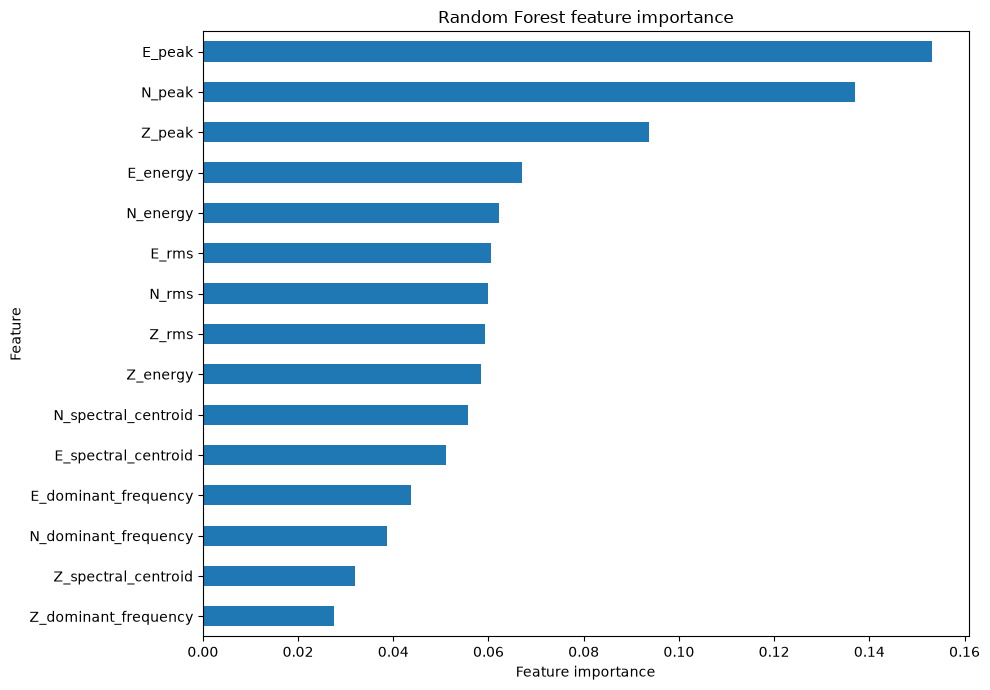

In [16]:
plt.figure(figsize=(10, 7))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()